# Phase 2: Recommender Model Benchmarking with Cornac

This notebook evaluates multiple recommendation algorithms (Popularity Baseline, Neighborhood CF, Matrix Factorization, and SVD) across multiple datasets (MovieLens-1M and FilmTrust) using the **Cornac** framework.

We evaluate models on both **Ranking Accuracy** (`NDCG@10`, `Recall@10`, `Precision@10`, `MAP`, `MRR`) and **Popularity Bias / Item Exposure Inequality** (`Gini@10`).

In [3]:
!pip install cornac

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cornac
from cornac.datasets import movielens, filmtrust
from cornac.eval_methods import RatioSplit
from cornac.models import MostPop, UserKNN, ItemKNN, BPR, PMF, MF, SVD
from cornac.metrics import NDCG, Recall, Precision, MAP, MRR

print(f"Cornac Version: {cornac.__version__}")

Cornac Version: 2.6.0


## 1. Load Datasets

We load two implicit feedback datasets:
1. **MovieLens 1M**: ~1 million interaction records from 6,038 users on 3,533 items.
2. **FilmTrust**: ~35,497 interaction records from 1,508 users on 2,071 items.

In [4]:
# Load MovieLens 1M tuple interactions (user_id, item_id, rating)
ml_1m_data = movielens.load_feedback(variant="1M")
print(f"MovieLens 1M interactions count: {len(ml_1m_data):,}")

# Load FilmTrust tuple interactions
filmtrust_data = filmtrust.load_feedback()
print(f"FilmTrust interactions count: {len(filmtrust_data):,}")

Data from https://files.grouplens.org/datasets/movielens/ml-1m.zip
will be cached into /root/.cornac/ml-1m/ratings.dat


0.00B [00:00, ?B/s]

Unzipping ...
File cached!
MovieLens 1M interactions count: 1,000,209
Data from https://static.preferred.ai/cornac/datasets/filmtrust/filmtrust.zip
will be cached into /root/.cornac/filmtrust/ratings.txt


0.00B [00:00, ?B/s]

Unzipping ...
File cached!
FilmTrust interactions count: 35,497


## 2. Define Train/Test Evaluation Splits

We use an **80/20 Train/Test RatioSplit** per user, filtering positive interactions with `rating_threshold = 4.0` for implicit binarization.

In [5]:
SEED = 42

# MovieLens 1M Evaluation Split
eval_ml1m = RatioSplit(
    data=ml_1m_data,
    test_size=0.2,
    rating_threshold=4.0,
    seed=SEED,
    exclude_unknowns=True,
    verbose=True
)

# FilmTrust Evaluation Split
eval_filmtrust = RatioSplit(
    data=filmtrust_data,
    test_size=0.2,
    rating_threshold=3.5,  # FilmTrust ratings range 0.5 - 4.0
    seed=SEED,
    exclude_unknowns=True,
    verbose=True
)

rating_threshold = 4.0
exclude_unknowns = True
---
Training data:
Number of users = 6040
Number of items = 3675
Number of ratings = 800167
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
---
Test data:
Number of users = 6040
Number of items = 3675
Number of ratings = 200006
Number of unknown users = 0
Number of unknown items = 0
---
Total users = 6040
Total items = 3675
rating_threshold = 3.5
exclude_unknowns = True
---
Training data:
Number of users = 1488
Number of items = 1933
Number of ratings = 28394
Max rating = 4.0
Min rating = 0.5
Global mean = 3.0
---
Test data:
Number of users = 1488
Number of items = 1933
Number of ratings = 6907
Number of unknown users = 0
Number of unknown items = 0
---
Total users = 1488
Total items = 1933


/usr/local/lib/python3.12/dist-packages/cornac/data/dataset.py:335: UserWarning: 3 duplicated observations are removed!
  warnings.warn("%d duplicated observations are removed!" % dup_count)


## 3. Define Model Instantiator Function

We define a function returning fresh model instances for each dataset experiment:
1. `MostPop`: Popularity-based baseline (max popularity bias).
2. `UserKNN`: User-based Collaborative Filtering with Cosine similarity.
3. `ItemKNN`: Item-based Collaborative Filtering with Cosine similarity.
4. `BPR`: Bayesian Personalized Ranking matrix factorization.
5. `PMF`: Probabilistic Matrix Factorization.
6. `MF`: Matrix Factorization.
7. `SVD`: Singular Value Decomposition recommendation model.

In [6]:
def get_models(seed=SEED):
    return [
        MostPop(name="MostPop"),
        UserKNN(k=20, similarity="cosine", name="UserKNN"),
        ItemKNN(k=20, similarity="cosine", name="ItemKNN"),
        BPR(k=20, max_iter=100, learning_rate=0.01, lambda_reg=0.01, seed=seed, name="BPR"),
        PMF(k=20, max_iter=100, learning_rate=0.001, lambda_reg=0.01, seed=seed, name="PMF"),
        MF(k=20, max_iter=100, learning_rate=0.01, lambda_reg=0.01, seed=seed, name="MF"),
        SVD(k=20, max_iter=100, learning_rate=0.01, lambda_reg=0.01, seed=seed, name="SVD")
    ]

## 4. Define Evaluation Metrics & Popularity Bias Gini Function

We evaluate top-10 recommendations using both Ranking Accuracy & Gini Exposure Inequality:

In [7]:
metrics = [
    NDCG(k=10),
    Recall(k=10),
    Precision(k=10),
    MAP(),
    MRR()
]

def compute_gini(exposure_counts):
    x = np.sort(exposure_counts)
    n = len(x)
    cum = np.cumsum(x)
    if cum[-1] == 0:
        return 0.0
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

def calculate_model_gini(model, eval_method, top_k=10):
    test_users = list(eval_method.test_set.user_data.keys())
    num_items = eval_method.total_items
    item_counts = np.zeros(num_items)
    
    for uid in test_users:
        recs = model.recommend(user_id=uid, k=top_k, remove_seen=True)
        if recs is not None:
            for item_idx in recs:
                item_counts[item_idx] += 1
                
    return compute_gini(item_counts)

## 5. Run Benchmark Experiment on MovieLens 1M

In [8]:
print("=== Running Experiment on MovieLens 1M ===")
exp_ml1m = cornac.Experiment(
    eval_method=eval_ml1m,
    models=get_models(),
    metrics=metrics,
    user_based=True
)
exp_ml1m.run()

=== Running Experiment on MovieLens 1M ===

[MostPop] Training started!

[MostPop] Evaluation started!


Ranking:   0%|          | 0/6033 [00:00<?, ?it/s]


[UserKNN] Training started!


  0%|          | 0/6040 [00:00<?, ?it/s]


[UserKNN] Evaluation started!


...


[MF] Training started!

[MF] Evaluation started!


Ranking:   0%|          | 0/6033 [00:00<?, ?it/s]


[SVD] Training started!

[SVD] Evaluation started!


Ranking:   0%|          | 0/6033 [00:00<?, ?it/s]


TEST:
...
        |    MAP |    MRR | NDCG@10 | Precision@10 | Recall@10 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
MostPop | 0.0878 | 0.3107 |  0.1489 |       0.1262 |    0.0782 |    0.0498 |   6.2029
UserKNN | 0.0147 | 0.0178 |  0.0003 |       0.0004 |    0.0003 |    3.1838 | 108.7161
ItemKNN | 0.0308 | 0.0809 |  0.0367 |       0.0408 |    0.0121 |    1.1964 | 150.8472
BPR     | 0.1546 | 0.4345 |  0.2359 |       0.1966 |    0.1423 |   20.3007 |   8.6148
PMF     | 0.0311 | 0.0964 |  0.0404 |       0.0423 |    0.0269 |   41.4867 |   7.4952
MF      | 0.0254 | 0.0781 |  0.0283 |       0.0279 |    0.0134 |    1.8369 |   9.7842
SVD     | 0.0254 | 0.0781 |  0.0283 |       0.0279 |    0.0134 |    1.8273 |   9.7277



## 6. Run Benchmark Experiment on FilmTrust

In [9]:
print("=== Running Experiment on FilmTrust ===")
exp_filmtrust = cornac.Experiment(
    eval_method=eval_filmtrust,
    models=get_models(),
    metrics=metrics,
    user_based=True
)
exp_filmtrust.run()

=== Running Experiment on FilmTrust ===

[MostPop] Training started!

[MostPop] Evaluation started!


Ranking:   0%|          | 0/1246 [00:00<?, ?it/s]


[UserKNN] Training started!


  0%|          | 0/1488 [00:00<?, ?it/s]


[UserKNN] Evaluation started!


...


[MF] Training started!

[MF] Evaluation started!


Ranking:   0%|          | 0/1246 [00:00<?, ?it/s]


[SVD] Training started!

[SVD] Evaluation started!


Ranking:   0%|          | 0/1246 [00:00<?, ?it/s]


TEST:
...
        |    MAP |    MRR | NDCG@10 | Precision@10 | Recall@10 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
MostPop | 0.2500 | 0.3452 |  0.3038 |       0.1334 |    0.4497 |    0.0046 |   0.7810
UserKNN | 0.0023 | 0.0025 |  0.0000 |       0.0000 |    0.0000 |    0.1468 |   2.5879
ItemKNN | 0.0035 | 0.0069 |  0.0025 |       0.0017 |    0.0050 |    0.1149 |   3.4518
BPR     | 0.2354 | 0.3182 |  0.2839 |       0.1315 |    0.4339 |    0.2982 |   1.0916
PMF     | 0.0101 | 0.0121 |  0.0020 |       0.0014 |    0.0039 |    1.7989 |   0.8945
MF      | 0.0174 | 0.0443 |  0.0223 |       0.0106 |    0.0295 |    0.0578 |   1.1061
SVD     | 0.0174 | 0.0443 |  0.0223 |       0.0106 |    0.0295 |    0.0597 |   1.1015



## 7. Comparative Analysis & Visualization (Accuracy vs Popularity Bias)

We extract metrics and compute the Gini exposure inequality for each model across both datasets.

     Dataset   Model      MAP      MRR  NDCG@10  Precision@10  Recall@10  Train (s)   Test (s)  Gini@10
MovieLens 1M MostPop 0.087767 0.310664 0.148912      0.126200   0.078163   0.049780   6.202860 0.994984
MovieLens 1M UserKNN 0.014714 0.017840 0.000326      0.000402   0.000274   3.183829 108.716097 0.996851
MovieLens 1M ItemKNN 0.030780 0.080902 0.036711      0.040773   0.012092   1.196380 150.847225 0.900550
MovieLens 1M     BPR 0.154574 0.434534 0.235917      0.196637   0.142269  20.300650   8.614772 0.924704
MovieLens 1M     PMF 0.031128 0.096366 0.040412      0.042262   0.026883  41.486712   7.495162 0.993670
MovieLens 1M      MF 0.025390 0.078123 0.028272      0.027857   0.013436   1.836915   9.784153 0.836607
MovieLens 1M     SVD 0.025390 0.078123 0.028272      0.027857   0.013436   1.827285   9.727652 0.836607
   FilmTrust MostPop 0.249960 0.345246 0.303846      0.133366   0.449673   0.004627   0.781009 0.986559
   FilmTrust UserKNN 0.002278 0.002514 0.000000      0.000000   

/tmp/ipykernel_986/3183856291.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ml1m, x="Model", y="NDCG@10", ax=axes[0, 0], palette="Blues_d")
/tmp/ipykernel_986/3183856291.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ml1m, x="Model", y="Gini@10", ax=axes[0, 1], palette="Purples_d")
/tmp/ipykernel_986/3183856291.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_filmtrust, x="Model", y="NDCG@10", ax=axes[1, 0], palette="Oranges_d")
/tmp/ipykernel_986/3183856291.py:62: FutureWarning: 

Passing `palette` w

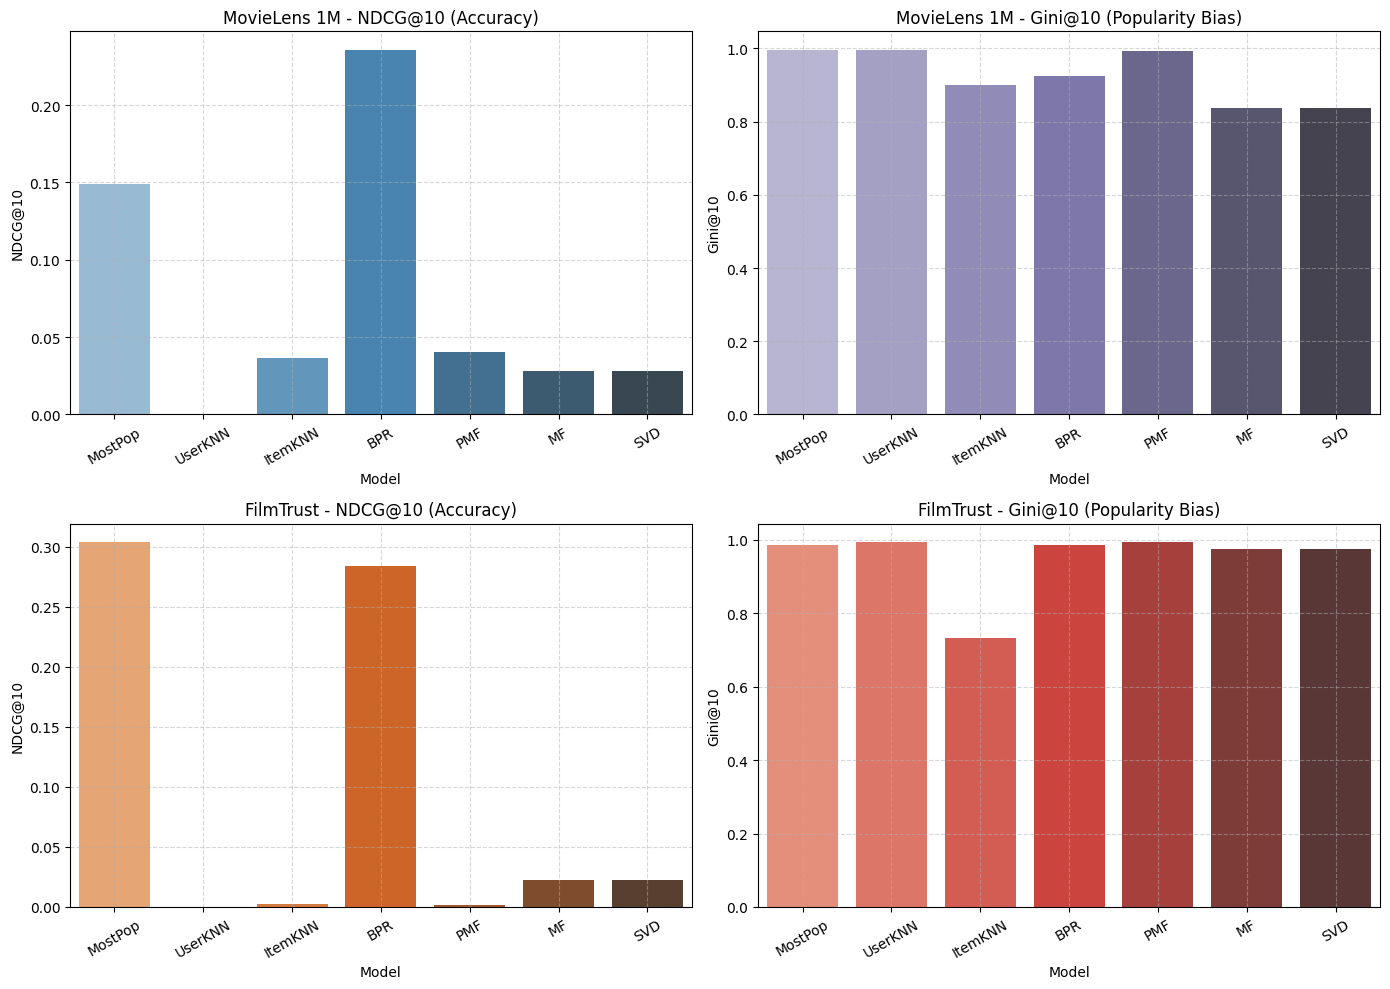

In [12]:
def extract_experiment_df(exp, eval_method, dataset_name):
    rows = []
    test_user_indices = list(eval_method.test_set.user_data.keys())
    train_mat = eval_method.train_set.csr_matrix
    num_items = eval_method.total_items

    # exp.models contains the trained models, exp.result contains the metrics summary
    for model, res in zip(exp.models, exp.result):
        row = {"Dataset": dataset_name, "Model": res.model_name}
        row.update(res.metric_avg_results)

        # Compute Gini Popularity Bias using model.rank() on internal numeric indices
        item_counts = np.zeros(num_items)
        for u_idx in test_user_indices:
            all_items = np.arange(eval_method.train_set.num_items)
            if u_idx < train_mat.shape[0]:
                seen_items = train_mat.getrow(u_idx).indices
                mask = np.ones(len(all_items), dtype=bool)
                mask[seen_items] = False
                unseen_items = all_items[mask]
            else:
                unseen_items = all_items
            
            # Rank top-10 unseen items for this user
            item_rank, _ = model.rank(user_idx=u_idx, item_indices=unseen_items, k=10)
            for item_idx in item_rank[:10]:
                item_counts[item_idx] += 1

        row["Gini@10"] = compute_gini(item_counts)
        rows.append(row)
        
    return pd.DataFrame(rows)

df_ml1m = extract_experiment_df(exp_ml1m, eval_ml1m, "MovieLens 1M")
df_filmtrust = extract_experiment_df(exp_filmtrust, eval_filmtrust, "FilmTrust")

df_all = pd.concat([df_ml1m, df_filmtrust], ignore_index=True)
print(df_all.to_string(index=False))

# Plot NDCG@10 and Gini@10 Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MovieLens 1M NDCG
sns.barplot(data=df_ml1m, x="Model", y="NDCG@10", ax=axes[0, 0], palette="Blues_d")
axes[0, 0].set_title("MovieLens 1M - NDCG@10 (Accuracy)")
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

# MovieLens 1M Gini
sns.barplot(data=df_ml1m, x="Model", y="Gini@10", ax=axes[0, 1], palette="Purples_d")
axes[0, 1].set_title("MovieLens 1M - Gini@10 (Popularity Bias)")
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].grid(True, linestyle="--", alpha=0.5)

# FilmTrust NDCG
sns.barplot(data=df_filmtrust, x="Model", y="NDCG@10", ax=axes[1, 0], palette="Oranges_d")
axes[1, 0].set_title("FilmTrust - NDCG@10 (Accuracy)")
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

# FilmTrust Gini
sns.barplot(data=df_filmtrust, x="Model", y="Gini@10", ax=axes[1, 1], palette="Reds_d")
axes[1, 1].set_title("FilmTrust - Gini@10 (Popularity Bias)")
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
